In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
df = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/sales_base.csv')

In [6]:
df.dtypes

date       datetime64[ns]
revenue           float64
cogs              float64
dtype: object

In [5]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df.groupby('date').agg({
    'revenue': 'sum',
    'cogs': 'sum'
}).reset_index()

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


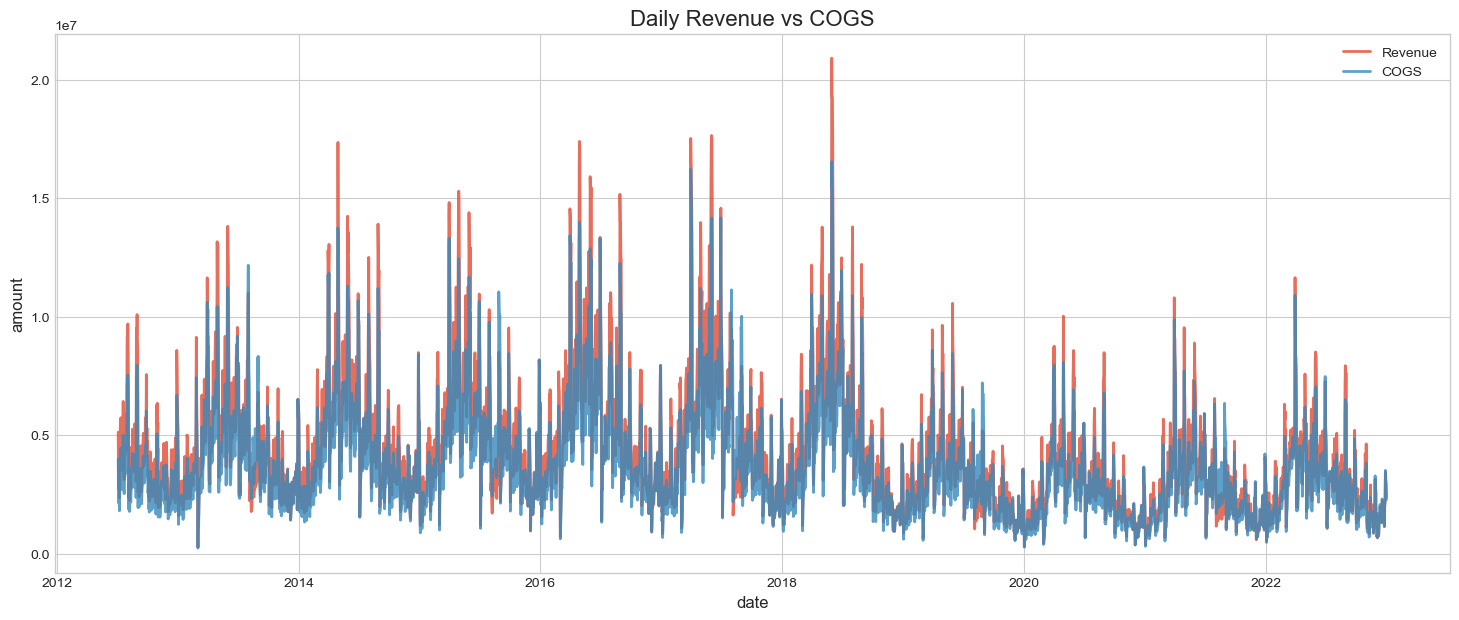

In [29]:
plt.figure(figsize=(18,7))

plt.plot(
    df['date'],
    df['revenue'],
    linewidth=2,
    alpha=0.8,
    label='Revenue'
)

plt.plot(
    df['date'],
    df['cogs'],
    linewidth=2,
    alpha=0.8,
    label='COGS'
)

plt.title('Daily Revenue vs COGS', fontsize=16)

plt.xlabel('date')
plt.ylabel('amount')

plt.legend()

plt.grid(True)
plt.savefig(
    'chart1_1.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [15]:
df['GrossProfit'] = df['revenue'] - df['cogs']

In [16]:
df

,date,revenue,cogs,GrossProfit
0,2012-07-04,5123547.94,3982991.19,1140556.75
1,2012-07-05,2751773.45,2150580.23,601193.22
2,2012-07-06,3054029.42,2517632.84,536396.58
3,2012-07-07,2667930.94,2108246.62,559684.32
4,2012-07-08,2360851.90,1808622.79,552229.11
...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,-84318.58
3829,2022-12-28,3448729.20,3513621.00,-64891.80
3830,2022-12-29,3083944.33,3170787.10,-86842.77
3831,2022-12-30,2884668.76,3022292.15,-137623.39


In [17]:
df['gross_margin'] = df['GrossProfit'] / df['revenue']

In [18]:
df

,date,revenue,cogs,GrossProfit,gross_margin
0,2012-07-04,5123547.94,3982991.19,1140556.75,0.222611
1,2012-07-05,2751773.45,2150580.23,601193.22,0.218475
2,2012-07-06,3054029.42,2517632.84,536396.58,0.175636
3,2012-07-07,2667930.94,2108246.62,559684.32,0.209782
4,2012-07-08,2360851.90,1808622.79,552229.11,0.233911
...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,-84318.58,-0.040141
3829,2022-12-28,3448729.20,3513621.00,-64891.80,-0.018816
3830,2022-12-29,3083944.33,3170787.10,-86842.77,-0.028160
3831,2022-12-30,2884668.76,3022292.15,-137623.39,-0.047709


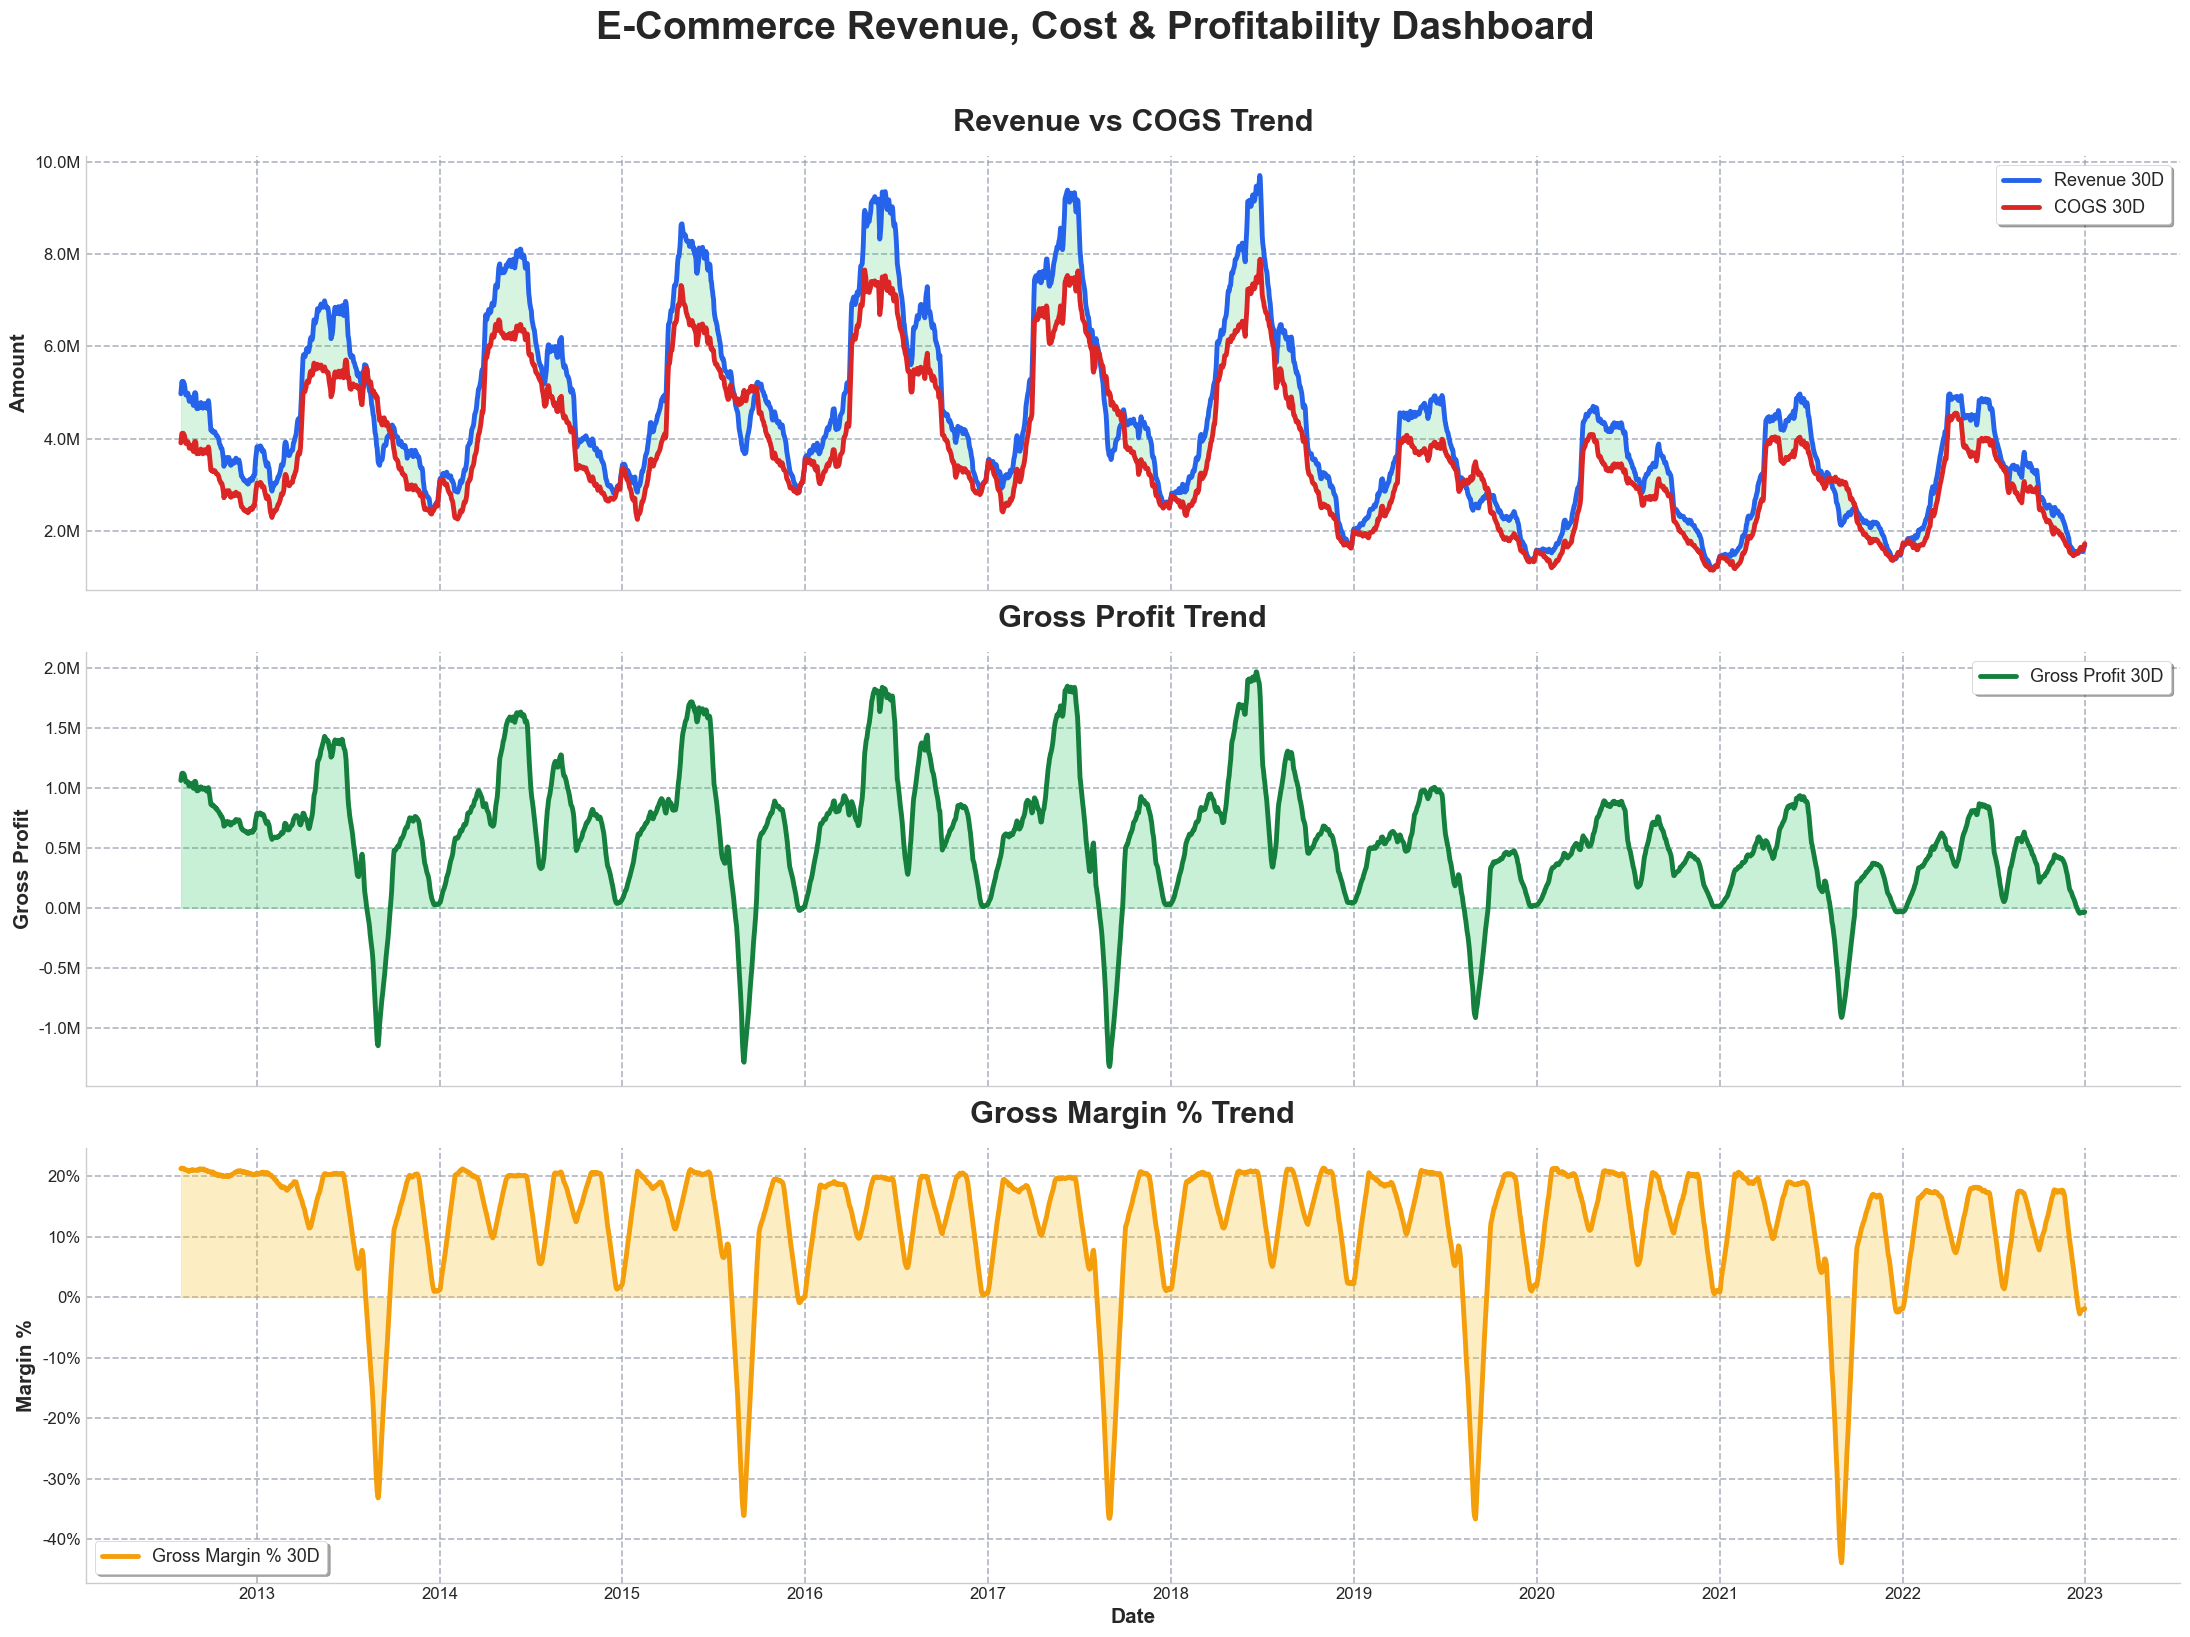

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

# =========================================================
# STYLE
# =========================================================

plt.style.use('seaborn-v0_8-whitegrid')

# =========================================================
# ROLLING FEATURES
# =========================================================

df['Revenue_30D'] = (
    df['revenue']
    .rolling(30)
    .mean()
)

df['COGS_30D'] = (
    df['cogs']
    .rolling(30)
    .mean()
)

df['GrossProfit_30D'] = (
    df['GrossProfit']
    .rolling(30)
    .mean()
)

df['GrossMargin_30D'] = (
    df['gross_margin']
    .rolling(30)
    .mean()
)

# =========================================================
# CREATE DASHBOARD
# =========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(22,16),
    sharex=True
)

# Background
fig.patch.set_facecolor('white')

# =========================================================
# FORMATTERS
# =========================================================

money_formatter = ticker.FuncFormatter(
    lambda x, pos: f'{x/1e6:.1f}M'
)

percent_formatter = ticker.FuncFormatter(
    lambda x, pos: f'{x:.0%}'
)

# =========================================================
# CHART 1
# Revenue vs COGS
# =========================================================

axes[0].plot(
    df['date'],
    df['Revenue_30D'],
    linewidth=3.5,
    label='Revenue 30D',
    color='#2563eb'
)

axes[0].plot(
    df['date'],
    df['COGS_30D'],
    linewidth=3.5,
    label='COGS 30D',
    color='#dc2626'
)

axes[0].fill_between(
    df['date'],
    df['Revenue_30D'],
    df['COGS_30D'],
    alpha=0.18,
    color='#22c55e'
)

axes[0].set_title(
    'Revenue vs COGS Trend',
    fontsize=22,
    fontweight='bold',
    pad=18
)

axes[0].set_ylabel(
    'Amount',
    fontsize=15,
    fontweight='bold'
)

axes[0].yaxis.set_major_formatter(
    money_formatter
)

axes[0].legend(
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True
)

# Grid mạnh hơn
axes[0].set_axisbelow(True)

axes[0].grid(
    True,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    color='#9ca3af'
)

# =========================================================
# CHART 2
# Gross Profit
# =========================================================

axes[1].plot(
    df['date'],
    df['GrossProfit_30D'],
    linewidth=3.5,
    color='#15803d',
    label='Gross Profit 30D'
)

axes[1].fill_between(
    df['date'],
    df['GrossProfit_30D'],
    alpha=0.25,
    color='#22c55e'
)

axes[1].set_title(
    'Gross Profit Trend',
    fontsize=22,
    fontweight='bold',
    pad=18
)

axes[1].set_ylabel(
    'Gross Profit',
    fontsize=15,
    fontweight='bold'
)

axes[1].yaxis.set_major_formatter(
    money_formatter
)

axes[1].legend(
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True
)

axes[1].set_axisbelow(True)

axes[1].grid(
    True,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    color='#9ca3af'
)

# =========================================================
# CHART 3
# Gross Margin %
# =========================================================

axes[2].plot(
    df['date'],
    df['GrossMargin_30D'],
    linewidth=3.5,
    color='#f59e0b',
    label='Gross Margin % 30D'
)

axes[2].fill_between(
    df['date'],
    df['GrossMargin_30D'],
    alpha=0.28,
    color='#fbbf24'
)

axes[2].set_title(
    'Gross Margin % Trend',
    fontsize=22,
    fontweight='bold',
    pad=18
)

axes[2].set_ylabel(
    'Margin %',
    fontsize=15,
    fontweight='bold'
)

axes[2].set_xlabel(
    'Date',
    fontsize=15,
    fontweight='bold'
)

axes[2].yaxis.set_major_formatter(
    percent_formatter
)

axes[2].legend(
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True
)

axes[2].set_axisbelow(True)

axes[2].grid(
    True,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    color='#9ca3af'
)

# =========================================================
# AXIS FORMATTING
# =========================================================

for ax in axes:

    # Tick size
    ax.tick_params(
        axis='x',
        labelsize=12
    )

    ax.tick_params(
        axis='y',
        labelsize=12
    )

    # Remove top/right border
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# =========================================================
# X-AXIS DATE FORMAT
# =========================================================

axes[2].xaxis.set_major_locator(
    mdates.YearLocator()
)

axes[2].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

# =========================================================
# OVERALL TITLE
# =========================================================

fig.suptitle(
    'E-Commerce Revenue, Cost & Profitability Dashboard',
    fontsize=28,
    fontweight='bold',
    y=1.02
)

# =========================================================
# LAYOUT
# =========================================================

plt.subplots_adjust(
    hspace=0.38
)

plt.tight_layout()

# =========================================================
# SAVE
# =========================================================

plt.savefig(
    'chart1_2.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()